<a href="https://www.kaggle.com/code/lalit7881/fifa-world-cup-all-matches-1930-2026-eda?scriptVersionId=340900774" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns 
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/laxmikantaroy/fifa-world-cup-all-matches-19302026/fifa_world_cup_all_matches_1930_2026.csv


In [2]:
# Import necessary libraries and suppress warnings
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')  # ensure Agg backend for matplotlib
import matplotlib.pyplot as plt
plt.switch_backend('Agg')  # if only plt is imported, explicitly switch backend
get_ipython().run_line_magic('matplotlib', 'inline')

import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc

# Helper for resolving the data file path
from pathlib import Path

DATA_ROOTS = [
    Path('/kaggle/input'),
    Path('/kaggle/input'),
    Path('/kaggle/input/datasets'),
]

def resolve_data_file(file_name=None, suffixes=None):
    suffixes = tuple(suffixes or [])
    for root in DATA_ROOTS:
        if not root.exists():
            continue
        matches = [p for p in root.rglob('*') if p.is_file()]
        if file_name:
            exact = [p for p in matches if p.name == file_name]
            if exact:
                return exact[0]
        if suffixes:
            typed = [p for p in matches if p.suffix.lower() in suffixes]
            if typed:
                return typed[0]
    raise FileNotFoundError(f'Could not resolve data file: {file_name or suffixes}')

print('Imports and helper functions set up successfully.')

Imports and helper functions set up successfully.


In [3]:
# Data Import and Setup
import os

# Attempt to resolve the data file using the helper
try:
    data_file = resolve_data_file(file_name='fifa_world_cup_all_matches_1930_2026.csv', suffixes=['.csv'])
    print(f"Data file located at: {data_file}")
except FileNotFoundError as e:
    print(e)

# Load the CSV data into a pandas DataFrame
df = pd.read_csv(data_file, encoding='utf-8')
print('Data loaded successfully.')
print(f"Dataset contains {df.shape[0]} rows and {df.shape[1]} columns.")

Data file located at: /kaggle/input/datasets/laxmikantaroy/fifa-world-cup-all-matches-19302026/fifa_world_cup_all_matches_1930_2026.csv
Data loaded successfully.
Dataset contains 1069 rows and 23 columns.


In [4]:
# Data Cleaning and Preprocessing
# Convert the 'date' column to datetime format
try:
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    print('Date column converted to datetime format successfully.')
except Exception as e:
    print('Error converting date column:', e)
    # Note: Using errors='coerce' ensures that malformed dates become NaT, preventing crashes.

# Check for missing values in key numeric columns
missing_summary = df.isnull().sum()
print('Missing values in each column:')
print(missing_summary)

Date column converted to datetime format successfully.
Missing values in each column:
match_id                     0
world_cup_year               0
host_country                 0
date                         0
stage                        0
round_raw                    0
group                      290
team1                        0
team2                        0
halftime_score_team1       709
halftime_score_team2       709
fulltime_score_team1         1
fulltime_score_team2         1
extra_time_score_team1     987
extra_time_score_team2     987
penalty_score_team1       1030
penalty_score_team2       1030
winner                       0
result_method                0
stadium                      0
city                         1
total_goals_team1            0
total_goals_team2            0
dtype: int64


Generating summary statistics...


,match_id,world_cup_year,host_country,date,stage,round_raw,group,team1,team2,halftime_score_team1,...,extra_time_score_team1,extra_time_score_team2,penalty_score_team1,penalty_score_team2,winner,result_method,stadium,city,total_goals_team1,total_goals_team2
count,1069.000000,1069.000000,1069,1069,1069,1069,779,1069,1069,360.000000,...,82.000000,82.000000,39.000000,39.000000,1069,1069,1069,1068,1069.000000,1069.000000
unique,NaN,NaN,19,NaN,13,38,18,90,93,NaN,...,NaN,NaN,NaN,NaN,71,6,219,181,NaN,NaN
top,NaN,NaN,"Canada, Mexico, United States",NaN,Group Stage,Matchday 2,Group A,Brazil,Mexico,NaN,...,NaN,NaN,NaN,NaN,Draw,Normal Time,Estadio Azteca,Mexico City,NaN,NaN
freq,NaN,NaN,104,NaN,768,154,81,82,42,NaN,...,NaN,NaN,NaN,NaN,199,793,24,28,NaN,NaN
mean,535.000000,1992.772685,NaN,1993-04-08 03:09:56.071094400,NaN,NaN,NaN,NaN,NaN,0.769444,...,1.463415,1.231707,3.230769,3.102564,NaN,NaN,NaN,NaN,0.627689,0.424696
min,1.000000,1930.000000,NaN,1930-07-13 00:00:00,NaN,NaN,NaN,NaN,NaN,0.000000,...,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000
25%,268.000000,1974.000000,NaN,1974-07-03 00:00:00,NaN,NaN,NaN,NaN,NaN,0.000000,...,1.000000,1.000000,3.000000,2.000000,NaN,NaN,NaN,NaN,0.000000,0.000000
50%,535.000000,1998.000000,NaN,1998-06-16 00:00:00,NaN,NaN,NaN,NaN,NaN,1.000000,...,1.000000,1.000000,3.000000,3.000000,NaN,NaN,NaN,NaN,0.000000,0.000000
75%,802.000000,2014.000000,NaN,2014-06-21 00:00:00,NaN,NaN,NaN,NaN,NaN,1.000000,...,2.000000,2.000000,4.000000,4.000000,NaN,NaN,NaN,NaN,1.000000,0.000000
max,1069.000000,2026.000000,NaN,2026-07-19 00:00:00,NaN,NaN,NaN,NaN,NaN,5.000000,...,6.000000,5.000000,5.000000,5.000000,NaN,NaN,NaN,NaN,8.000000,7.000000


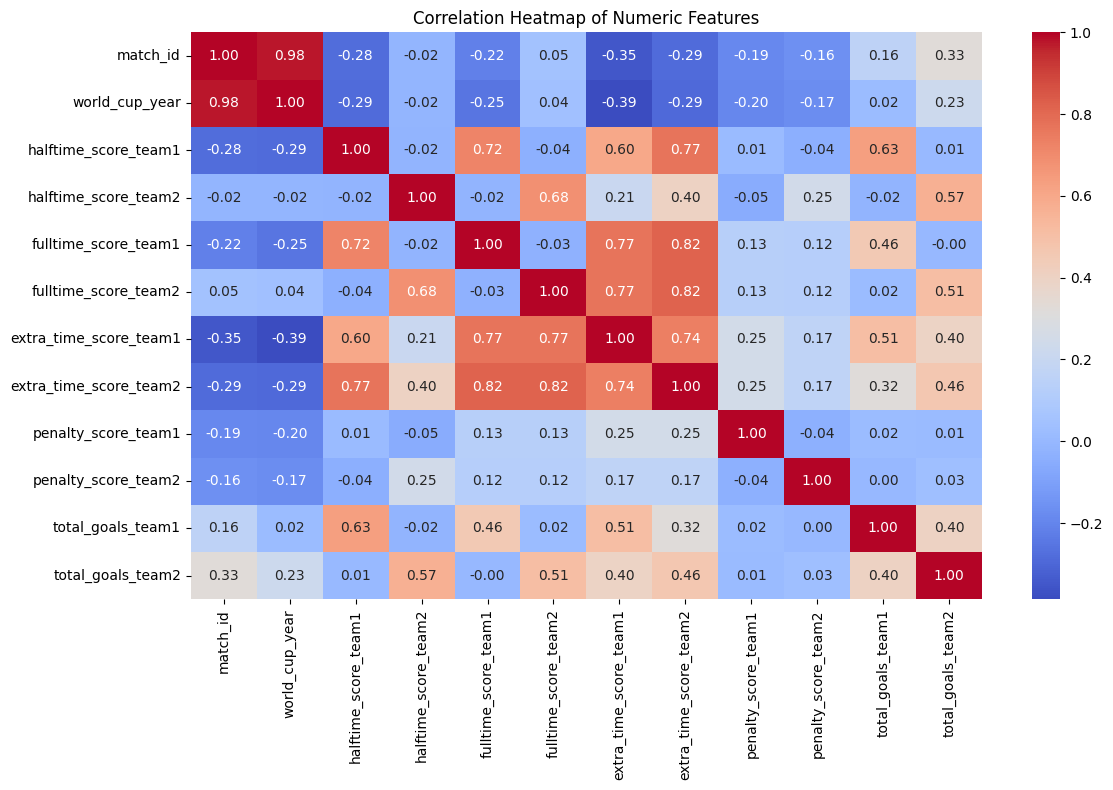

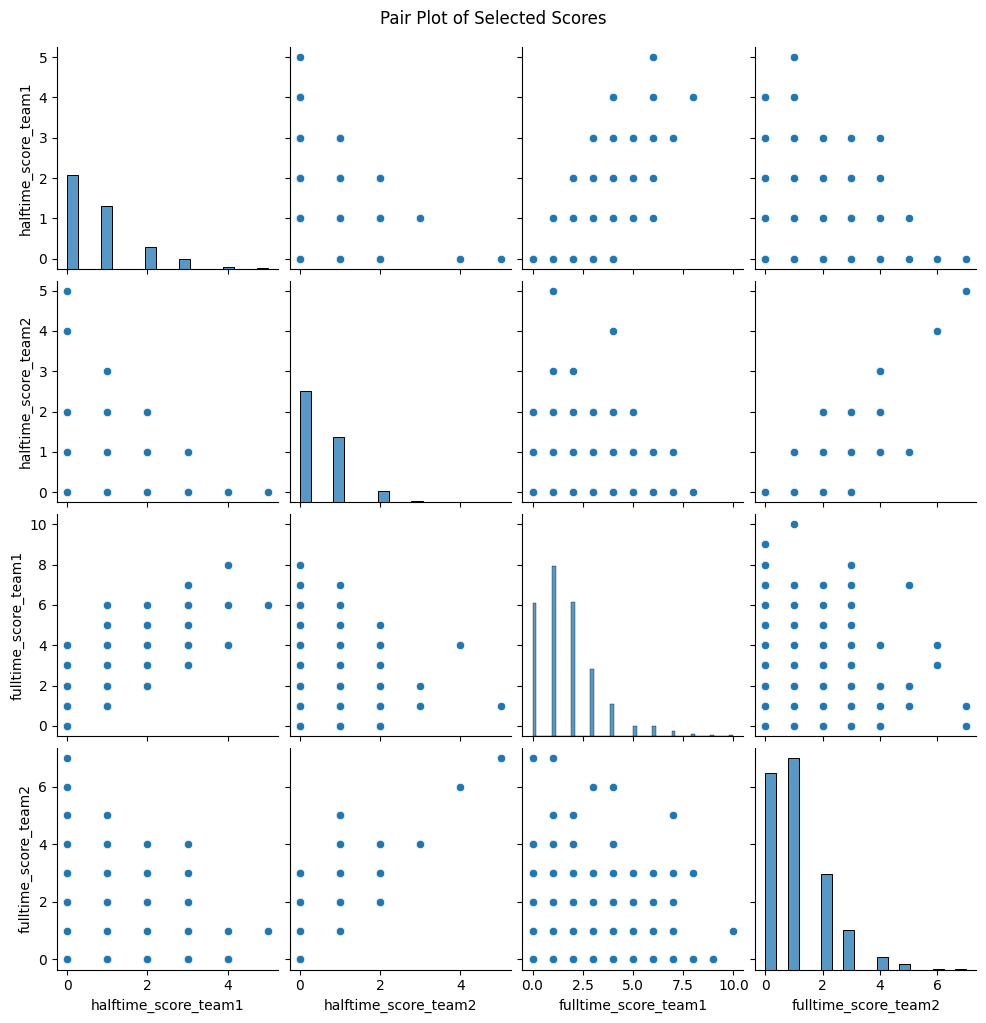

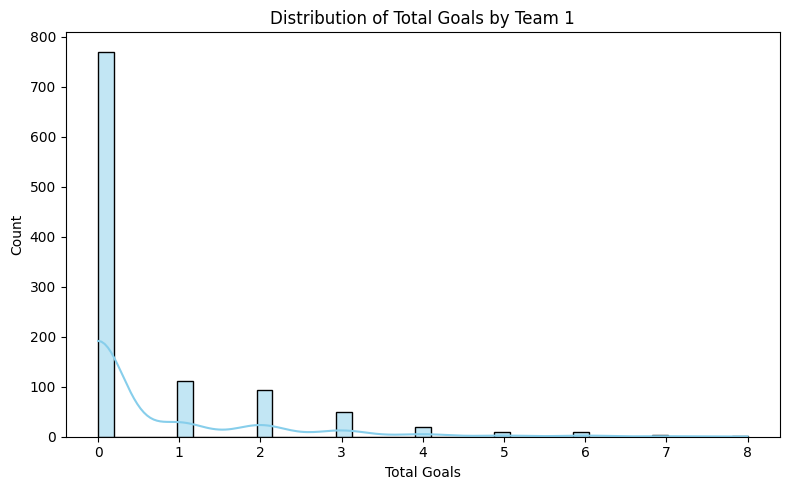

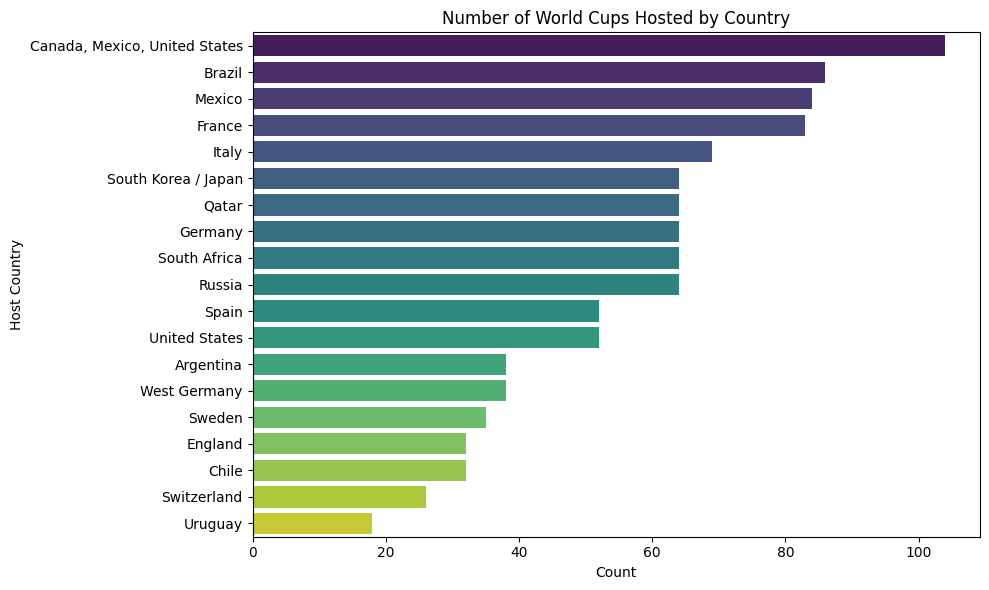

In [5]:
# Exploratory Data Analysis
print('Generating summary statistics...')
display(df.describe(include='all'))

# Visualisation 1: Heatmap of correlations among numeric features (only if 4 or more numeric columns)
numeric_df = df.select_dtypes(include=[np.number])
if numeric_df.shape[1] >= 4:
    plt.figure(figsize=(12, 8))
    corr = numeric_df.corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
    plt.title('Correlation Heatmap of Numeric Features')
    plt.tight_layout()
    plt.show()
else:
    print('Not enough numeric columns for a meaningful correlation heatmap.')

# Visualisation 2: Pair plot of selected numeric features to look at relationships
selected_features = ['halftime_score_team1', 'halftime_score_team2', 'fulltime_score_team1', 'fulltime_score_team2']
if all(col in df.columns for col in selected_features):
    sns.pairplot(df[selected_features])
    plt.suptitle('Pair Plot of Selected Scores', y=1.02)
    plt.show()
else:
    print('Some selected features are missing from the dataset.')

# Visualisation 3: Histogram for total goals by team1
if 'total_goals_team1' in df.columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(df['total_goals_team1'].dropna(), kde=True, color='skyblue')
    plt.title('Distribution of Total Goals by Team 1')
    plt.xlabel('Total Goals')
    plt.tight_layout()
    plt.show()
else:
    print('Column total_goals_team1 not found.')

# Visualisation 4: Bar plot for host countries counts
plt.figure(figsize=(10, 6))
sns.countplot(y='host_country', data=df, order=df['host_country'].value_counts().index, palette='viridis')
plt.title('Number of World Cups Hosted by Country')
plt.xlabel('Count')
plt.ylabel('Host Country')
plt.tight_layout()
plt.show()

Prediction Accuracy: 0.73


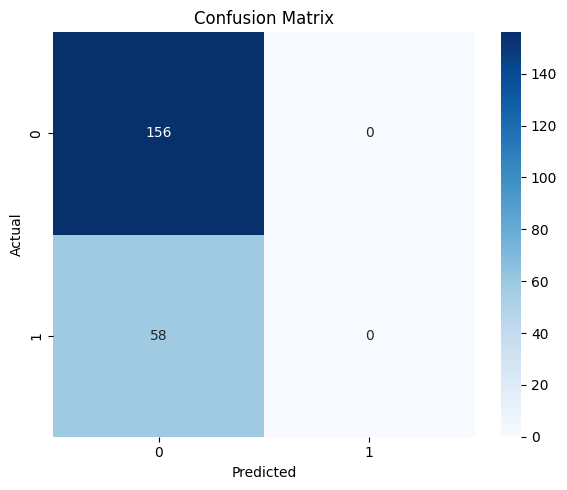

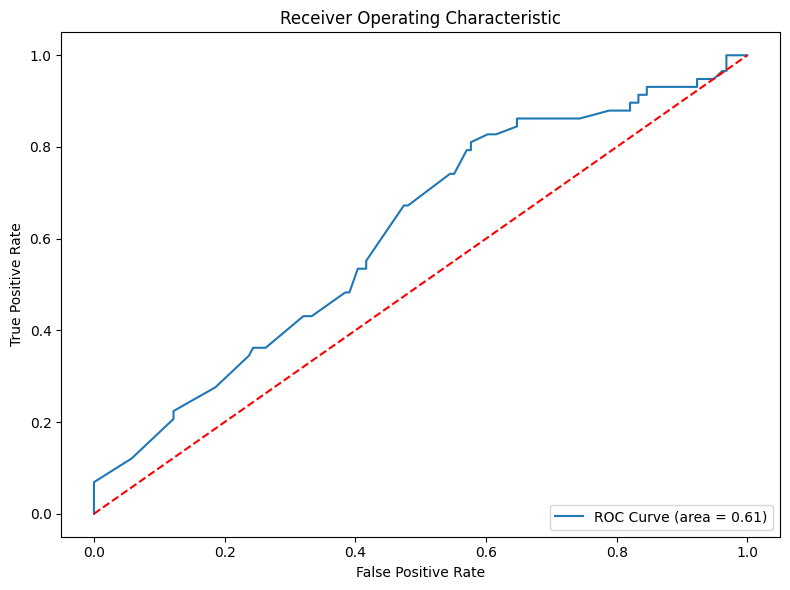

In [6]:
df['draw'] = (df['fulltime_score_team1'] == df['fulltime_score_team2']).astype(int)

# Define features and target
# We'll use a few numeric columns as predictors. Note: a more sophisticated model might use additional features.
features = ['total_goals_team1', 'total_goals_team2', 'world_cup_year']
for feat in features:
    if feat not in df.columns:
        raise ValueError(f"Expected feature '{feat}' not found in the dataframe.")

X = df[features].fillna(0)  # Filling missing values with zero as a simple strategy
y = df['draw']

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the logistic regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Prediction and evaluation
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Prediction Accuracy: {acc:.2f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# ROC Curve
y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Thank you ..pls upvote!!!!!!!!!!